In [39]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor

# Check current directory to confirm file paths
print("Current Working Directory:", os.getcwd())

# Load the messy dataset generated by your script
df = pd.read_csv("../data/student_performance_dataset.csv")
print("Initial Dataset Shape:", df.shape)

Current Working Directory: d:\IBI-Student-Performance-ML\Notebook
Initial Dataset Shape: (2500, 12)


In [40]:
# 1. Remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

# 2. Fill missing numerical values with Median
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in numerical_cols:
    df[col] = df[col].fillna(df[col].median())

# 3. Fill missing categorical values with Mode
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

print("Cleaned Dataset Shape:", df.shape)

Duplicate rows found: 0
Cleaned Dataset Shape: (2500, 12)


C:\Users\shamp\AppData\Local\Temp\ipykernel_15224\1015577130.py:11: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


In [14]:
# 1. Load the dataset
df = pd.read_csv("../data/" + "student_performance_dataset.csv")

# 2. Check and remove duplicate rows
print("Duplicate rows found:", df.duplicated().sum())
df = df.drop_duplicates()

# 3. Check for any missing/null values
print("\nMissing values per column:")
print(df.isnull().sum())

# 4. Show the final clean dataset shape
print("\nFinal clean data shape:", df.shape)

Duplicate rows found: 20

Missing values per column:
StudentID                     0
Age                          40
Gender                        0
AttendancePercentage         40
StudyHoursPerWeek             0
AssignmentCompletionRate      0
PreviousExamScore             0
ParticipationScore            0
ExtracurricularActivities     0
InternetAccessAtHome          0
ParentEducationLevel         40
FinalExamScore                0
dtype: int64

Final clean data shape: (2500, 12)


In [21]:
import pandas as pd
import numpy as np

np.random.seed(42)

n = 2500

data = {
    "StudentID": range(1, n+1),
    "Age": np.random.randint(15, 20, n),
    "Gender": np.random.choice(["Male", "Female"], n),
    "AttendancePercentage": np.random.randint(60, 101, n),
    "StudyHoursPerWeek": np.random.randint(5, 41, n),
    "AssignmentCompletionRate": np.random.randint(40, 101, n),
    "PreviousExamScore": np.random.randint(40, 101, n),
    "ParticipationScore": np.random.randint(1, 11, n),
    "ExtracurricularActivities": np.random.choice(["Yes", "No"], n),
    "InternetAccessAtHome": np.random.choice(["Yes", "No"], n),
    "ParentEducationLevel": np.random.choice(
        ["High School", "Graduate", "Postgraduate"], n
    )
}

df = pd.DataFrame(data)


df["FinalExamScore"] = (
    0.25 * df["AttendancePercentage"] +
    0.20 * df["StudyHoursPerWeek"] +
    0.20 * df["AssignmentCompletionRate"] +
    0.25 * df["PreviousExamScore"] +
    1.5 * df["ParticipationScore"] +
    np.random.normal(0,5,n)
)

df["FinalExamScore"] = df["FinalExamScore"].clip(0,100)


df.to_csv("../data/student_performance_dataset.csv", index=False)

df.head()

,StudentID,Age,Gender,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,ExtracurricularActivities,InternetAccessAtHome,ParentEducationLevel,FinalExamScore
0,1,18,Male,95,9,60,72,3,No,No,Graduate,65.091772
1,2,19,Female,93,38,91,69,5,Yes,Yes,Postgraduate,68.191767
2,3,17,Male,68,5,57,51,1,Yes,No,High School,44.599570
3,4,19,Female,87,36,82,83,4,Yes,No,Postgraduate,71.771355
4,5,19,Male,70,30,91,51,8,No,Yes,High School,66.423067


In [22]:
df.shape

(2500, 12)

In [23]:
# Remove identical duplicate rows
df = df.drop_duplicates(keep="first")

print(f"Remaining duplicate count: {df.duplicated().sum()}")
print(f"Row count after removing duplicates: {df.shape[0]}")

Remaining duplicate count: 0
Row count after removing duplicates: 2500


In [24]:
df = pd.read_csv("../data/student_performance_dataset.csv")

In [25]:
df = pd.read_csv("../data/student_performance_dataset.csv")

In [26]:
df.head()

,StudentID,Age,Gender,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,ExtracurricularActivities,InternetAccessAtHome,ParentEducationLevel,FinalExamScore
0,1,18,Male,95,9,60,72,3,No,No,Graduate,65.091772
1,2,19,Female,93,38,91,69,5,Yes,Yes,Postgraduate,68.191767
2,3,17,Male,68,5,57,51,1,Yes,No,High School,44.599570
3,4,19,Female,87,36,82,83,4,Yes,No,Postgraduate,71.771355
4,5,19,Male,70,30,91,51,8,No,Yes,High School,66.423067


In [27]:
df.shape

(2500, 12)

In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   StudentID                  2500 non-null   int64  
 1   Age                        2500 non-null   int64  
 2   Gender                     2500 non-null   str    
 3   AttendancePercentage       2500 non-null   int64  
 4   StudyHoursPerWeek          2500 non-null   int64  
 5   AssignmentCompletionRate   2500 non-null   int64  
 6   PreviousExamScore          2500 non-null   int64  
 7   ParticipationScore         2500 non-null   int64  
 8   ExtracurricularActivities  2500 non-null   str    
 9   InternetAccessAtHome       2500 non-null   str    
 10  ParentEducationLevel       2500 non-null   str    
 11  FinalExamScore             2500 non-null   float64
dtypes: float64(1), int64(7), str(4)
memory usage: 234.5 KB


In [29]:
df.isnull().sum()

StudentID                    0
Age                          0
Gender                       0
AttendancePercentage         0
StudyHoursPerWeek            0
AssignmentCompletionRate     0
PreviousExamScore            0
ParticipationScore           0
ExtracurricularActivities    0
InternetAccessAtHome         0
ParentEducationLevel         0
FinalExamScore               0
dtype: int64

In [30]:
df.duplicated().sum()

np.int64(0)

In [31]:
df = df.drop_duplicates()

df.shape


(2500, 12)

In [32]:
df.describe()

,StudentID,Age,AttendancePercentage,StudyHoursPerWeek,AssignmentCompletionRate,PreviousExamScore,ParticipationScore,FinalExamScore
count,2500.00000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000,2500.000000
mean,1250.50000,17.011600,79.864800,22.382400,69.985600,70.018400,5.470400,64.288757
std,721.83216,1.429504,11.496895,10.265823,17.774042,17.589526,2.854537,9.271323
min,1.00000,15.000000,60.000000,5.000000,40.000000,40.000000,1.000000,29.599406
25%,625.75000,16.000000,70.000000,14.000000,55.000000,55.000000,3.000000,58.222085
50%,1250.50000,17.000000,80.000000,22.000000,70.000000,70.000000,5.000000,64.148096
75%,1875.25000,18.000000,90.000000,31.000000,85.000000,86.000000,8.000000,70.748101
max,2500.00000,19.000000,100.000000,40.000000,100.000000,100.000000,10.000000,93.689134


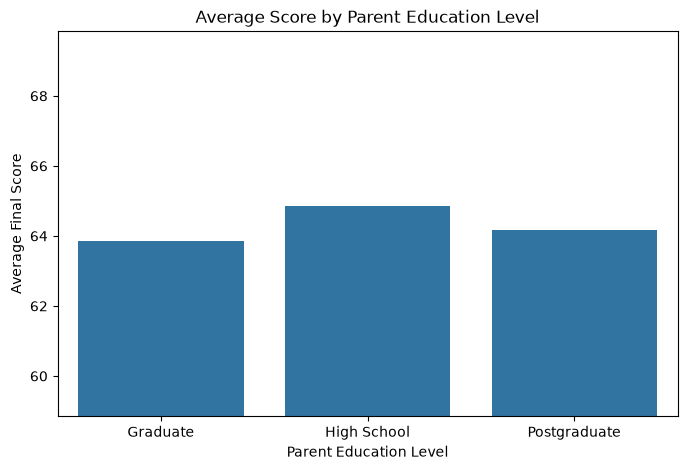

In [33]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

df["FinalExamScore"] = pd.to_numeric(df["FinalExamScore"], errors="coerce")
education_score = df.groupby("ParentEducationLevel")["FinalExamScore"].mean()

plt.figure(figsize=(8, 5))
sns.barplot(x=education_score.index, y=education_score.values)

ymin = max(0, education_score.min() - 5)
ymax = education_score.max() + 5
plt.ylim(ymin, ymax)

plt.title("Average Score by Parent Education Level")
plt.xlabel("Parent Education Level")
plt.ylabel("Average Final Score")

plt.show()

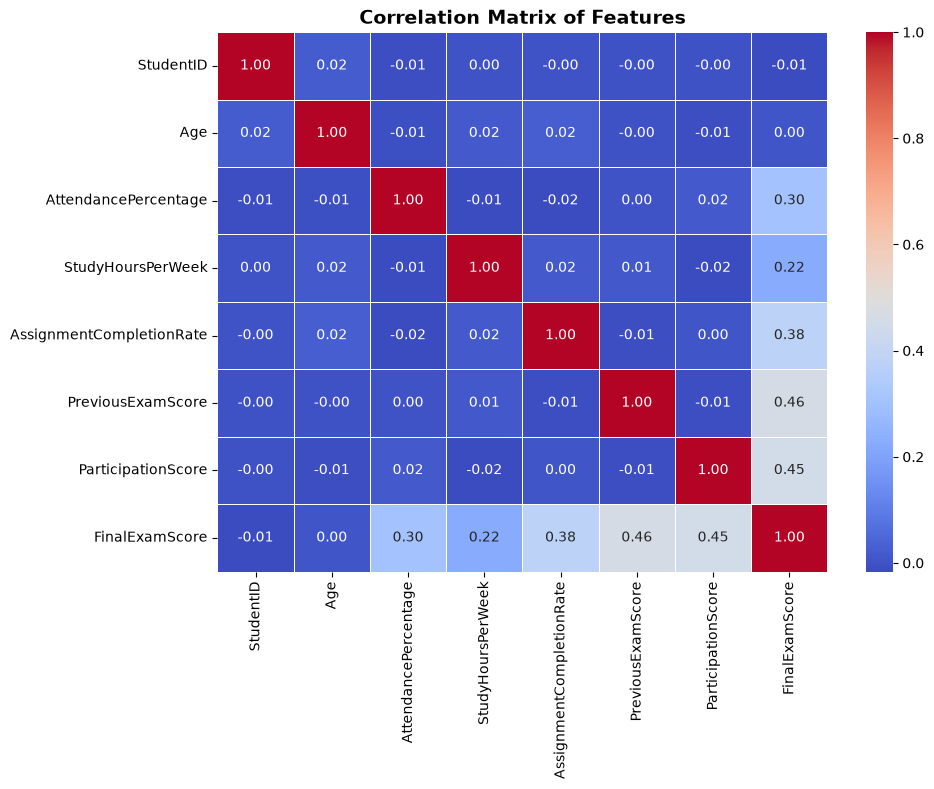

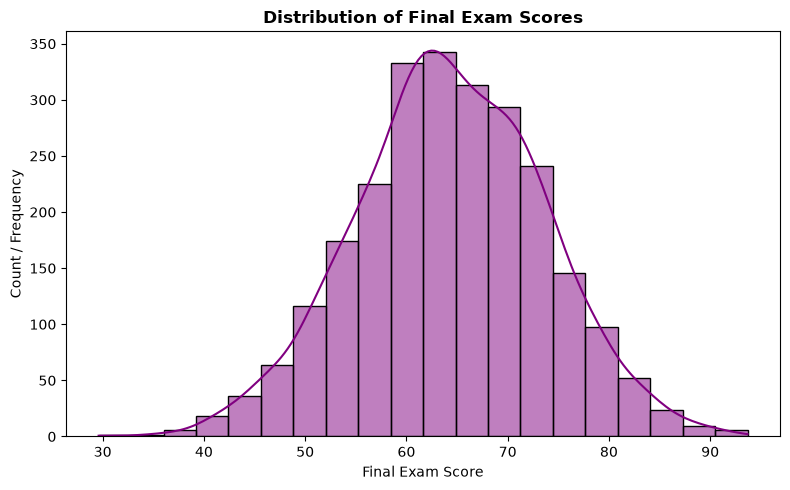

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---- 1. CORRELATION ANALYSIS (HEATMAP) ----
plt.figure(figsize=(10, 8))
# We select only the numerical columns to check how they correlate
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# ---- 2. SCORE DISTRIBUTION (HISTOGRAM) ----
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="FinalExamScore", kde=True, color="purple", bins=20)
plt.title("Distribution of Final Exam Scores", fontsize=12, fontweight="bold")
plt.xlabel("Final Exam Score")
plt.ylabel("Count / Frequency")
plt.tight_layout()
plt.show()

In [35]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==========================================
# STEP 1: ENCODE CATEGORICAL VARIABLES
# ==========================================
# Convert Binary text columns to 1s and 0s
df['ExtracurricularActivities'] = df['ExtracurricularActivities'].map({'Yes': 1, 'No': 0})
df['InternetAccessAtHome'] = df['InternetAccessAtHome'].map({'Yes': 1, 'No': 0})
df['Gender'] = df['Gender'].map({'Male': 1, 'Female': 0})

# Convert Parent Education Level to ordered numbers
edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
df['ParentEducationLevel'] = df['ParentEducationLevel'].map(edu_map)

# Drop any accidental missing values to be safe
df = df.dropna()

# ==========================================
# STEP 2: SPLIT THE DATA
# ==========================================
# Drop 'StudentID' (useless for prediction) and 'FinalExamScore' (the target variable)
X = df.drop(columns=['StudentID', 'FinalExamScore'])
y = df['FinalExamScore']

# Split: 80% for training the AI, 20% for testing its accuracy
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ==========================================
# STEP 3: TRAIN THE MODEL
# ==========================================
# Initialize and train a Random Forest Regressor
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Make predictions on test data
y_pred = model.predict(X_test)

# ==========================================
# STEP 4: EVALUATE PERFORMANCE
# ==========================================
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("==== Model Performance Metrics ====")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score (Accuracy): {r2:.2f}")

==== Model Performance Metrics ====
Mean Absolute Error (MAE): 4.20
Mean Squared Error (MSE): 27.84
Root Mean Squared Error (RMSE): 5.28
R² Score (Accuracy): 0.68


In [36]:
def student_performance_predictor(trained_model, feature_columns):
    print("\n=============================================")
    print("🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓")
    print("=============================================\n")
    print("Please enter the student's details below to predict their final score.")
    
    try:
        # 1. Gather numerical inputs with safety limits
        attendance = float(input("Enter Attendance Percentage (0 to 100): "))
        if not (0 <= attendance <= 100):
            print("❌ Error: Attendance percentage must be between 0 and 100.")
            return

        study_hours = float(input("Enter Average Study Hours Per Week (e.g., 0 to 50): "))
        if study_hours < 0:
            print("❌ Error: Study hours cannot be negative.")
            return

        assignment_rate = float(input("Enter Assignment Completion Rate (0 to 100): "))
        if not (0 <= assignment_rate <= 100):
            print("❌ Error: Assignment rate must be between 0 and 100.")
            return

        prev_score = float(input("Enter Previous Exam Score (0 to 100): "))
        if not (0 <= prev_score <= 100):
            print("❌ Error: Previous exam score must be between 0 and 100.")
            return

        participation = float(input("Enter Classroom Participation Score (0 to 100): "))
        if not (0 <= participation <= 100):
            print("❌ Error: Participation score must be between 0 and 100.")
            return
            
        age = float(input("Enter Student Age: "))
        if age <= 0:
            print("❌ Error: Age must be a positive number.")
            return

        # 2. Gather categorical inputs and manually map them to match training
        gender_input = input("Enter Gender (Male/Female): ").strip().capitalize()
        if gender_input not in ['Male', 'Female']:
            print("❌ Error: Gender must be 'Male' or 'Female'.")
            return
        gender = 1 if gender_input == 'Male' else 0

        extra_input = input("Involved in Extracurricular Activities? (Yes/No): ").strip().capitalize()
        if extra_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        extracurricular = 1 if extra_input == 'Yes' else 0

        internet_input = input("Has Internet Access At Home? (Yes/No): ").strip().capitalize()
        if internet_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        internet = 1 if internet_input == 'Yes' else 0

        print("\nParent Education levels: 'High School', 'Graduate', 'Postgraduate'")
        edu_input = input("Enter Parent Education Level: ").strip().title()
        edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
        if edu_input not in edu_map:
            print("❌ Error: Invalid education level entered.")
            return
        parent_edu = edu_map[edu_input]

        # 3. Structure the input data row to precisely match the model's feature alignment
        # Construct dictionary mapping feature names to user input variables
        user_data_dict = {
            'Age': age,
            'Gender': gender,
            'AttendancePercentage': attendance,
            'StudyHoursPerWeek': study_hours,
            'AssignmentCompletionRate': assignment_rate,
            'PreviousExamScore': prev_score,
            'ParticipationScore': participation,
            'ExtracurricularActivities': extracurricular,
            'InternetAccessAtHome': internet,
            'ParentEducationLevel': parent_edu
        }
        
        # Build array strictly in the correct column order from training (X)
        input_features = [user_data_dict[col] for col in feature_columns]
        
        # 4. Generate and display the prediction
        predicted_score = trained_model.predict([input_features])[0]
        
        # Clamp bounds to valid scale 0-100% just in case
        predicted_score = max(0, min(100, predicted_score))
        
        print("\n=============================================")
        print(f"🔮 Predicted Final Exam Score: {predicted_score:.1f}%")
        print("=============================================")

    except ValueError:
        print("\n❌ Error: Invalid numerical entry. Please enter valid numbers.")

# Run the console interface! 
# We pass the model and the exact training columns order list (X.columns)
student_performance_predictor(model, list(X.columns))


🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓

Please enter the student's details below to predict their final score.



Parent Education levels: 'High School', 'Graduate', 'Postgraduate'
❌ Error: Invalid education level entered.


In [37]:
import pandas as pd
import warnings

def student_performance_predictor(trained_model, feature_columns):
    print("\n=============================================")
    print("🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓")
    print("=============================================\n")
    print("Please enter the student's details below to predict their final score.")
    
    try:
        # 1. Gather numerical inputs with safety limits
        attendance = float(input("Enter Attendance Percentage (0 to 100): "))
        if not (0 <= attendance <= 100):
            print("❌ Error: Attendance percentage must be between 0 and 100.")
            return

        study_hours = float(input("Enter Average Study Hours Per Week (e.g., 0 to 50): "))
        if study_hours < 0:
            print("❌ Error: Study hours cannot be negative.")
            return

        assignment_rate = float(input("Enter Assignment Completion Rate (0 to 100): "))
        if not (0 <= assignment_rate <= 100):
            print("❌ Error: Assignment rate must be between 0 and 100.")
            return

        prev_score = float(input("Enter Previous Exam Score (0 to 100): "))
        if not (0 <= prev_score <= 100):
            print("❌ Error: Previous exam score must be between 0 and 100.")
            return

        participation = float(input("Enter Classroom Participation Score (0 to 100): "))
        if not (0 <= participation <= 100):
            print("❌ Error: Participation score must be between 0 and 100.")
            return
            
        age = float(input("Enter Student Age: "))
        if age <= 0:
            print("❌ Error: Age must be a positive number.")
            return

        # 2. Gather categorical inputs and manually map them to match training
        gender_input = input("Enter Gender (Male/Female): ").strip().capitalize()
        if gender_input not in ['Male', 'Female']:
            print("❌ Error: Gender must be 'Male' or 'Female'.")
            return
        gender = 1 if gender_input == 'Male' else 0

        extra_input = input("Involved in Extracurricular Activities? (Yes/No): ").strip().capitalize()
        if extra_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        extracurricular = 1 if extra_input == 'Yes' else 0

        internet_input = input("Has Internet Access At Home? (Yes/No): ").strip().capitalize()
        if internet_input not in ['Yes', 'No']:
            print("❌ Error: Please enter 'Yes' or 'No'.")
            return
        internet = 1 if internet_input == 'Yes' else 0

        print("\nParent Education levels: 'High School', 'Graduate', 'Postgraduate'")
        edu_input = input("Enter Parent Education Level: ").strip().title()
        edu_map = {'High School': 1, 'Graduate': 2, 'Postgraduate': 3}
        if edu_input not in edu_map:
            print("❌ Error: Invalid education level entered.")
            return
        parent_edu = edu_map[edu_input]

        # 3. Structure the input data row to precisely match the model's feature alignment
        user_data_dict = {
            'Age': age,
            'Gender': gender,
            'AttendancePercentage': attendance,
            'StudyHoursPerWeek': study_hours,
            'AssignmentCompletionRate': assignment_rate,
            'PreviousExamScore': prev_score,
            'ParticipationScore': participation,
            'ExtracurricularActivities': extracurricular,
            'InternetAccessAtHome': internet,
            'ParentEducationLevel': parent_edu
        }
        
        # Create a single-row DataFrame using training column order to eliminate Scikit-Learn warnings
        input_df = pd.DataFrame([user_data_dict], columns=feature_columns)
        
        # 4. Generate and display the prediction
        predicted_score = trained_model.predict(input_df)[0]
        predicted_score = max(0, min(100, predicted_score)) # Clamp bounds 0-100%
        
        print("\n=============================================")
        print(f"🔮 Predicted Final Exam Score: {predicted_score:.1f}%")
        print("=============================================")

    except ValueError:
        print("\n❌ Error: Invalid numerical entry. Please enter valid numbers.")

# Run the console interface! 
student_performance_predictor(model, list(X.columns))


🎓 STUDENT PERFORMANCE PREDICTION SYSTEM 🎓

Please enter the student's details below to predict their final score.

Parent Education levels: 'High School', 'Graduate', 'Postgraduate'

🔮 Predicted Final Exam Score: 62.4%


In [38]:
df.to_csv("student_performance_dataset.csv", index=False)